# Projet de Deep Reinforcement Learning (DRL)

Implémentation d'un **DQN (Deep Q-Network)** sur `CartPole-v1`.

L'agent doit simultanément :
- **Maintenir le poteau vertical**
- **Rester au centre** de l'espace de simulation

In [18]:
print("Hello, World!")

Hello, World!


In [19]:
import random, math
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Device:", device)

PyTorch: 2.6.0+cu124 | Device: cuda


In [20]:
env = gym.make("CartPole-v1")
env.unwrapped.x_threshold = 10   # espace de déplacement du cart (défaut : 2.4)
env.unwrapped.theta_threshold_radians = math.radians(45)


n_states  = env.observation_space.shape[0]
n_actions = env.action_space.n

print(f"États: {n_states}  |  Actions: {n_actions}  |  Limite piste: ±{env.unwrapped.x_threshold}")

États: 4  |  Actions: 2  |  Limite piste: ±10


In [21]:
class DQN(nn.Module):
    def __init__(self, n_states, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),   nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        return self.net(x)

In [22]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *transition):
        self.buffer.append(transition)

    def sample(self, n):
        return map(np.array, zip(*random.sample(self.buffer, n)))

    def __len__(self):
        return len(self.buffer)

In [23]:
# ── Hyperparamètres ──────────────────────────────────────────────────
GAMMA          = 0.99
LR             = 1e-3
EPS_START      = 1.0
EPS_END        = 0.01
EPS_DECAY      = 300       # decay plus rapide → exploitation plus tôt
BATCH_SIZE     = 128       # plus gros batch → gradients plus stables, GPU mieux utilisé
MAX_EPISODES   = 400
MAX_STEPS      = 5000
TAU            = 0.005     # soft target update (Polyak averaging)
CENTER_PENALTY = 0.5
SOLVE_THRESHOLD = 4500     # récompense moyenne pour considérer le problème résolu
SOLVE_WINDOW    = 20       # sur combien d'épisodes consécutifs

# ── Réseaux & optimiseur ──────────────────────────────────────────────
policy_net    = DQN(n_states, n_actions).to(device)
target_net    = DQN(n_states, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
optimizer     = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn       = nn.SmoothL1Loss()  # Huber loss : plus robuste que MSE
replay_buffer = ReplayBuffer(100_000)
steps_done    = 0

# ── Sélection d'action (ε-greedy) ────────────────────────────────────
def select_action(state):
    global steps_done
    eps = EPS_END + (EPS_START - EPS_END) * math.exp(-steps_done / EPS_DECAY)
    steps_done += 1
    if random.random() < eps:
        return random.randrange(n_actions), eps
    with torch.no_grad():
        q = policy_net(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0))
        return int(q.argmax()), eps

# ── Optimisation (Double DQN) ─────────────────────────────────────────
def optimize():
    if len(replay_buffer) < BATCH_SIZE:
        return None
    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

    s  = torch.tensor(states,                   dtype=torch.float32, device=device)
    a  = torch.tensor(actions,                  dtype=torch.long,    device=device).unsqueeze(1)
    r  = torch.tensor(rewards,                  dtype=torch.float32, device=device).unsqueeze(1)
    ns = torch.tensor(next_states,              dtype=torch.float32, device=device)
    d  = torch.tensor(dones.astype(np.float32), dtype=torch.float32, device=device).unsqueeze(1)

    q_pred = policy_net(s).gather(1, a)
    with torch.no_grad():
        # Double DQN : policy_net choisit l'action, target_net l'évalue
        best_actions = policy_net(ns).argmax(1, keepdim=True)
        q_next = target_net(ns).gather(1, best_actions)
        q_target = r + (1 - d) * GAMMA * q_next

    loss = loss_fn(q_pred, q_target)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
    optimizer.step()

    # Soft target update (chaque step au lieu de hard copy tous les N épisodes)
    for p, tp in zip(policy_net.parameters(), target_net.parameters()):
        tp.data.copy_(TAU * p.data + (1 - TAU) * tp.data)

    return loss.item()

In [24]:
all_rewards, all_losses = [], []

for episode in range(1, MAX_EPISODES + 1):
    state, _ = env.reset()
    ep_reward, ep_losses = 0.0, []

    for _ in range(MAX_STEPS):
        action, eps = select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Récompense façonnée : pénalise l'éloignement du centre
        reward -= CENTER_PENALTY * abs(next_state[0]) / env.unwrapped.x_threshold

        replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        ep_reward += reward

        loss = optimize()
        if loss: ep_losses.append(loss)
        if done: break

    all_rewards.append(ep_reward)
    all_losses.append(np.mean(ep_losses) if ep_losses else None)

    if episode % 10 == 0:
        mean10 = np.mean(all_rewards[-10:])
        print(f"Épisode {episode:3d}/{MAX_EPISODES}  |  Récompense moy (10 der.): {mean10:7.2f}  |  ε: {eps:.3f}")

    # Early stopping : arrête si résolu
    if len(all_rewards) >= SOLVE_WINDOW and np.mean(all_rewards[-SOLVE_WINDOW:]) >= SOLVE_THRESHOLD:
        print(f"\n✓ Résolu à l'épisode {episode} ! (moy {SOLVE_WINDOW} der.: {np.mean(all_rewards[-SOLVE_WINDOW:]):.0f})")
        break

print("Entraînement terminé.")

Épisode  10/400  |  Récompense moy (10 der.):   32.85  |  ε: 0.340
Épisode  20/400  |  Récompense moy (10 der.):   27.07  |  ε: 0.143
Épisode  30/400  |  Récompense moy (10 der.):   28.07  |  ε: 0.062
Épisode  40/400  |  Récompense moy (10 der.):   44.37  |  ε: 0.022
Épisode  50/400  |  Récompense moy (10 der.):   61.94  |  ε: 0.011
Épisode  60/400  |  Récompense moy (10 der.):  154.76  |  ε: 0.010
Épisode  70/400  |  Récompense moy (10 der.):  113.48  |  ε: 0.010
Épisode  80/400  |  Récompense moy (10 der.):  112.70  |  ε: 0.010
Épisode  90/400  |  Récompense moy (10 der.):  120.55  |  ε: 0.010
Épisode 100/400  |  Récompense moy (10 der.):  119.11  |  ε: 0.010
Épisode 110/400  |  Récompense moy (10 der.):   90.83  |  ε: 0.010
Épisode 120/400  |  Récompense moy (10 der.):   81.23  |  ε: 0.010
Épisode 130/400  |  Récompense moy (10 der.):   74.82  |  ε: 0.010
Épisode 140/400  |  Récompense moy (10 der.):   75.75  |  ε: 0.010
Épisode 150/400  |  Récompense moy (10 der.):   77.95  |  ε: 0

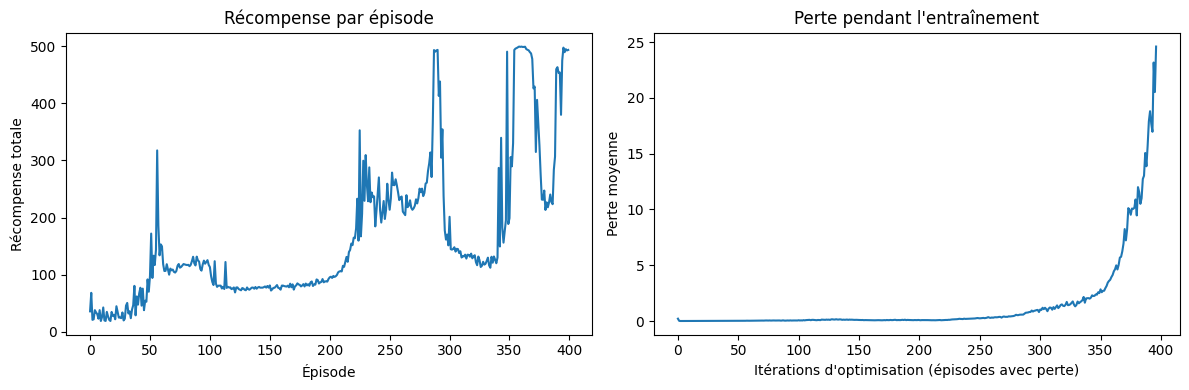

In [27]:
# Visualisation des récompenses et des pertes

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(all_rewards)
plt.xlabel("Épisode")
plt.ylabel("Récompense totale")
plt.title("Récompense par épisode")

plt.subplot(1, 2, 2)
plt.plot([l for l in all_losses if l is not None])
plt.xlabel("Itérations d'optimisation (épisodes avec perte)")
plt.ylabel("Perte moyenne")
plt.title("Perte pendant l'entraînement")

plt.tight_layout()
plt.show()

In [39]:
import time

def run_episode(env, render_delay=0.02):
    state, _ = env.reset()
    total_reward = 0
    start = time.time()
    while time.time() - start < 60:
        with torch.no_grad():
            q = policy_net(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0))
            action = int(q.argmax())
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        time.sleep(render_delay)
        if terminated or truncated:
            break
    return total_reward

# Évaluation sur 10 épisodes (sans délai)
rewards_eval = [run_episode(env, render_delay=0) for _ in range(10)]
print(f"Récompense moyenne (évaluation) : {np.mean(rewards_eval):.2f}")

# Visualisation en temps réel (1920x1080, même espace que l'entraînement)
env_render = gym.make("CartPole-v1", render_mode="human")
env_render.unwrapped.x_threshold = 10
env_render.unwrapped.theta_threshold_radians = math.radians(45)
env_render.unwrapped.screen_width  = 1920
env_render.unwrapped.screen_height = 1080
run_episode(env_render, render_delay=0.02)  # vitesse réelle
env_render.close()


Récompense moyenne (évaluation) : 500.00


In [31]:
env_render.close()